## Configuration

In [1]:
# Install dependencies
%pip install -q dagshub[jupyter]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.5/258.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.0 MB/s eta 0:00:00


In [2]:
!git config --global user.email {cheng.zhenwk@gmail.com}
!git config --global user.name {chengzwk}

In [3]:
USER_NAME = "chengzwk"

In [4]:
!dagshub login

import dagshub
TOKEN = dagshub.auth.get_token()

                                ❗❗❗ AUTHORIZATION REQUIRED ❗❗❗                                


Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=3da7d7a9-a443-40d9-8758-147bf828e6f8&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=a668cfbc6404ca903c060e0b19c8027e66b0c014cb027e7f652a7caa812cad51


⠦ Waiting for authorization
✅ OAuth token added


Accessing as chengzwk

In [5]:
!git clone https://dagshub.com/Omdena/FrankfurtGermanyChapter_UrbanGreenSpaceMappping.git workspace
%cd workspace

Cloning into 'workspace'...
remote: Enumerating objects: 2019, done.
remote: Counting objects: 100% (2019/2019), done.
remote: Compressing objects: 100% (1991/1991), done.
remote: Total 2019 (delta 692), reused 0 (delta 0), pack-reused 0
Receiving objects: 100% (2019/2019), 6.08 MiB | 2.58 MiB/s, done.
Resolving deltas: 100% (692/692), done.
/content/workspace


In [6]:
from dagshub.streaming import install_hooks

install_hooks()

Repository "Omdena/FrankfurtGermanyChapter_UrbanGreenSpaceMappping" is now hooked at path "/content/workspace".
Any calls to Python file access function like open() and listdir() inside of this directory will include results 
from the repository.

## Heatmap

In [7]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 72.3 MB/s eta 0:00:00


In [8]:
import os
import numpy as np
import rasterio
import rasterio.warp
import geopandas as gpd
from rasterio.transform import xy

In [9]:
# Get center coordinates of the chip
def get_chip_center(src):
    transform = src.transform
    crs = src.crs
    width, height = src.width, src.height

    # ✅ Get the actual center coordinates in the UTM projection
    center_x = width // 2
    center_y = height // 2
    utm_easting, utm_northing = rasterio.transform.xy(transform, center_y, center_x)

    # ✅ Convert UTM coordinates to Lat/Lon (EPSG:4326)
    lon, lat = rasterio.warp.transform(crs, 'EPSG:4326', [utm_easting], [utm_northing])
    lon, lat = lon[0], lat[0]  # Extract values from lists

    return lon, lat

In [10]:
# Function to compute vegetation fraction per chip
def compute_vegetation_ratio(mask_array):

    mask_array = np.transpose(mask_array, [1, 2, 0])               # move the axis for bands to the third axis
    mask_array[np.isnan(mask_array)] = 0                           # replace nan with 0
    classes = np.arange(2, 7)                                      # class numbers: 2, 3, 4, 5, 6
    mask_array = np.argmax(mask_array, axis=2, keepdims=True) + 2  # Convert fractional mask to binary mask

    total_pixels = mask_array.size
    veg_count = np.count_nonzero(np.isin(mask_array, [2, 5, 6]))
    veg_ratio = (veg_count / total_pixels)

    #vegetation_ratio = np.mean(mask)  # Compute average vegetation fraction

    return veg_ratio

In [11]:
IMAGE_DIR = 'MULC/VBWVA_8R'
MASK_DIR = "MULC/VBWVA_8R_masks"

# Iterate over image chips and extract vegetation data
chip_data = []  # Stores (latitude, longitude, vegetation_ratio)

image_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith('.tif')]

for i, filename in enumerate(image_files):
    print('{}/{} files, {}'.format(i, len(image_files), filename))

    mask_file = filename.replace('.tif', '_fractional_mask.tif')
    mask_path = os.path.join(MASK_DIR, mask_file)

    try:
        with open(mask_path, "rb") as f_mask:
            with rasterio.open(f_mask) as msk:
                lon, lat = get_chip_center(msk)
                mask_array = msk.read()  # Read all bands
                vegetation_ratio= compute_vegetation_ratio(mask_array)

        chip_data.append((lat, lon, vegetation_ratio, mask_file))

    except Exception as e:
        print(f'Error processing {mask_path}: {e}')
        continue


0/918 files, VBWVA_2016_319_3_GeoTIFF.tif
1/918 files, VBWVA_2016_214_3_GeoTIFF.tif
2/918 files, VBWVA_2016_97_2_GeoTIFF.tif
3/918 files, VBWVA_2016_173_1_GeoTIFF.tif
4/918 files, VBWVA_2016_201_3_GeoTIFF.tif
5/918 files, VBWVA_2016_109_2_GeoTIFF.tif
6/918 files, VBWVA_2016_305_3_GeoTIFF.tif
7/918 files, VBWVA_2016_16_3_GeoTIFF.tif
8/918 files, VBWVA_2016_208_1_GeoTIFF.tif
9/918 files, VBWVA_2016_21_3_GeoTIFF.tif
10/918 files, VBWVA_2016_277_3_GeoTIFF.tif
11/918 files, VBWVA_2016_248_1_GeoTIFF.tif
12/918 files, VBWVA_2016_252_3_GeoTIFF.tif
13/918 files, VBWVA_2016_198_1_GeoTIFF.tif
14/918 files, VBWVA_2016_55_3_GeoTIFF.tif
15/918 files, VBWVA_2016_0_3_GeoTIFF.tif
16/918 files, VBWVA_2016_91_1_GeoTIFF.tif
17/918 files, VBWVA_2016_55_2_GeoTIFF.tif
18/918 files, VBWVA_2016_164_3_GeoTIFF.tif
19/918 files, VBWVA_2016_109_1_GeoTIFF.tif
20/918 files, VBWVA_2016_161_2_GeoTIFF.tif
21/918 files, VBWVA_2016_316_2_GeoTIFF.tif
22/918 files, VBWVA_2016_164_1_GeoTIFF.tif
23/918 files, VBWVA_2016_124_

In [12]:
import pandas as pd

lat = [t[0] for t in chip_data]
lon = [t[1] for t in chip_data]
veg_ratio = [t[2] for t in chip_data]
mask_file = [t[3] for t in chip_data]
df = pd.DataFrame({'Lat':lat,'Long':lon,'veg_ratio': veg_ratio, 'file': mask_file})

In [14]:
import plotly.graph_objects as go

fig = go.Figure(go.Densitymapbox(lat=df.Lat,
                                 lon=df.Long,
                                 z=df.veg_ratio,
                                 radius=10,
                                 colorscale=[[0.0, 'blue',],[0.3,'lime'],[0.5,'yellow'],[0.7,'orange'],[1.0, 'red']],# custome colorscale
                                 zmin=0.0,
                                 zmax=1.0
                                ))

fig.update_layout(mapbox_style="carto-positron",
                  mapbox_center_lon=-76.00,
                  mapbox_center_lat=36.85,
                  mapbox_zoom=9)

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

## Simple statistics on the vegetation ratio of the dataset

In [13]:
df.head()

,Lat,Long,veg_ratio,file
0,36.862986,-76.077499,0.275146,VBWVA_2016_319_3_GeoTIFF_fractional_mask.tif
1,36.827565,-76.163119,0.436401,VBWVA_2016_214_3_GeoTIFF_fractional_mask.tif
2,36.849612,-76.263950,0.507996,VBWVA_2016_97_2_GeoTIFF_fractional_mask.tif
3,36.746526,-76.190570,0.245239,VBWVA_2016_173_1_GeoTIFF_fractional_mask.tif
4,36.873569,-76.178177,0.386963,VBWVA_2016_201_3_GeoTIFF_fractional_mask.tif


In [15]:
df['veg_ratio'].describe()  # Provides mean, std, min, max, quartiles, etc.

,veg_ratio
count,918.000000
mean,0.381411
std,0.194631
min,0.000000
25%,0.275146
50%,0.370941
75%,0.493286
max,0.999268


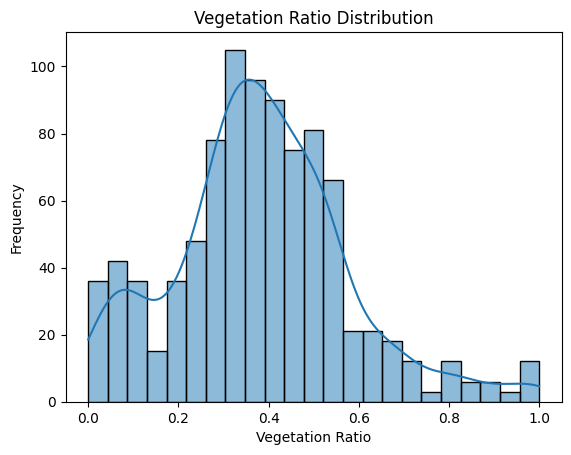

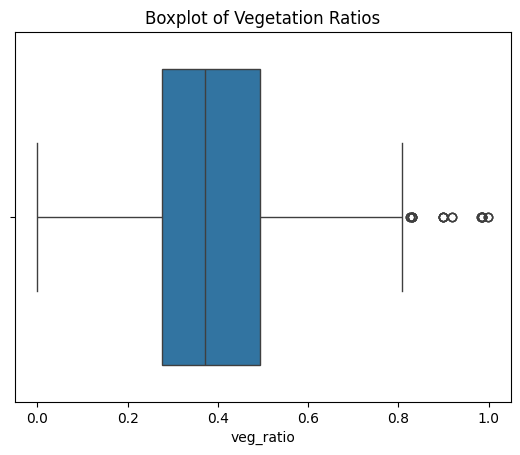

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['veg_ratio'], kde=True)
plt.title('Vegetation Ratio Distribution')
plt.xlabel('Vegetation Ratio')
plt.ylabel('Frequency')
plt.show()

sns.boxplot(x=df['veg_ratio'])
plt.title('Boxplot of Vegetation Ratios')
plt.show()

In [17]:
Q1 = df['veg_ratio'].quantile(0.25)
Q3 = df['veg_ratio'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['veg_ratio'] < (Q1 - 1.5 * IQR)) | (df['veg_ratio'] > (Q3 + 1.5 * IQR))]

In [18]:
outliers

,Lat,Long,veg_ratio,file
7,36.894969,-76.336523,0.899597,VBWVA_2016_16_3_GeoTIFF_fractional_mask.tif
34,36.871898,-76.336121,0.999268,VBWVA_2016_14_2_GeoTIFF_fractional_mask.tif
60,36.871898,-76.336121,0.999268,VBWVA_2016_14_3_GeoTIFF_fractional_mask.tif
67,36.883594,-76.321962,0.830261,VBWVA_2016_32_2_GeoTIFF_fractional_mask.tif
89,36.837767,-76.292464,0.829407,VBWVA_2016_62_1_GeoTIFF_fractional_mask.tif
91,36.871898,-76.336121,0.999268,VBWVA_2016_14_1_GeoTIFF_fractional_mask.tif
129,36.860523,-76.321565,0.982605,VBWVA_2016_30_1_GeoTIFF_fractional_mask.tif
144,36.860523,-76.321565,0.982605,VBWVA_2016_30_3_GeoTIFF_fractional_mask.tif
176,36.872059,-76.321763,0.918884,VBWVA_2016_31_2_GeoTIFF_fractional_mask.tif
177,36.826231,-76.292270,0.825012,VBWVA_2016_61_1_GeoTIFF_fractional_mask.tif


In [19]:
len(outliers)

30

## Save notebook

In [ ]:
from dagshub.notebook import save_notebook

USER_NAME = "chengzwk"
REPO_NAME = "omdena-frankfurt-ugs-unet"

repo = f"{USER_NAME}/{REPO_NAME}"
notebook_path = "Unet_Resnet50/data-exploration.ipynb"

# Add the commit message
commit_message = "Create notebook for data exploration. Plot heatmap for vegetation ratio of VBWVA. Calculate statistics."

save_notebook(repo=repo,
              branch = "main",
              path=notebook_path,
              commit_message=commit_message,
              versioning="git")